# Fáza 3 - Strojové učenie

**Autori:** Kosharova, Oliinyk

V tejto fáze implementujeme a porovnáme rôzne klasifikačné algoritmy pre predikciu cieľovej premennej.

## Import knižníc

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("✓ Všetky knižnice načítané")

✓ Všetky knižnice načítané


## Načítanie dát z fázy 2

In [2]:
metadata = joblib.load('phase2_metadata.pkl')

In [3]:
y_train = pd.read_csv("data/splits/y_train.csv").squeeze()
y_test = pd.read_csv("data/splits/y_test.csv").squeeze()
X_train = pd.read_csv("data/splits/X_train.csv")
X_test = X_test = pd.read_csv("data/splits/X_test.csv")

In [4]:

y_train_class = pd.cut(y_train, bins=3, labels=['Low', 'Medium', 'High'])
y_test_class = pd.cut(y_test, bins=3, labels=['Low', 'Medium', 'High'])

# y_train_class = pd.cut(y_train, bins=[-np.inf, 33, 66, np.inf], labels=['Low', 'Medium', 'High'])
# y_test_class = pd.cut(y_test, bins=[-np.inf, 33, 66, np.inf], labels=['Low', 'Medium', 'High'])

print("Distribúcia tried v trénovacích dátach:")
print(y_train_class.value_counts())
print("\nDistribúcia tried v testovacích dátach:")
print(y_test_class.value_counts())

Distribúcia tried v trénovacích dátach:
oximetry
High      10308
Low        6952
Medium        0
Name: count, dtype: int64

Distribúcia tried v testovacích dátach:
oximetry
High      2600
Low       1715
Medium       0
Name: count, dtype: int64


In [5]:
pipeline = metadata['pipeline']

X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

X_train_df = pd.DataFrame(
    X_train_transformed, 
    columns=metadata['selected_features'],
    index=X_train.index
)

X_test_df = pd.DataFrame(
    X_test_transformed, 
    columns=metadata['selected_features'],
    index=X_test.index
)

print(f"Transformované trénovacie dáta: {X_train_df.shape}")
print(f"Transformované testovacie dáta: {X_test_df.shape}")
display(X_train_df.head())

Transformované trénovacie dáta: (17260, 27)
Transformované testovacie dáta: (4315, 27)


,normal__HR,normal__RR,normal__Hb level,normal__latitude,normal__longitude,skewed__PRV,skewed__PVI,skewed__EtCO₂,skewed__Skin Temperature,skewed__Motion/Activity index,...,outliers__PPG waveform features,outliers__Respiratory effort,bounded__SpO₂,bounded__FiO₂,bounded__O₂ extraction ratio,categorical__station,categorical__continent,categorical__city,categorical__QoS,categorical__revision
0,-1.084072,-1.399442,-0.114041,0.260819,-0.021472,-0.865058,-0.643798,-0.914670,1.732545,0.594741,...,2.074418,0.123999,0.613265,0.708230,0.002463,286.0,0.0,3.0,2.0,1.662509e+09
1,-0.057022,-1.367893,1.423159,0.746629,0.013392,-0.530621,-1.184678,0.258077,0.445120,-0.290548,...,-1.145556,-1.042742,0.250280,0.000000,0.814629,333.0,6.0,138.0,2.0,1.694650e+09
2,1.087191,-0.102202,1.618998,-0.082867,0.976591,0.500024,1.054934,0.826237,-1.809321,0.375018,...,-0.178175,-0.324134,0.685325,0.000000,0.283883,310.0,4.0,57.0,1.0,1.600301e+09
3,0.531624,-0.883761,0.448668,0.992039,0.025488,-1.574626,-1.720791,1.470594,0.247802,1.755558,...,0.153506,0.219438,0.589396,0.530230,0.145728,264.0,6.0,5.0,2.0,1.697069e+09
4,0.192734,-0.710985,0.443676,-1.582281,-0.577254,-0.896079,-0.489088,-1.648281,0.951568,-1.575720,...,0.660015,0.482654,0.366579,0.408892,0.770313,377.0,1.0,9.0,2.0,1.641600e+09


## 3.1 ID3 Klasifikátor

Použijeme Decision Tree s entropy kritériom (čo je ekvivalent ID3).

### 3.1.A - ID3 klasifikátor s hĺbkou min 2 (2b)

In [6]:
id3_clf = DecisionTreeClassifier(
    criterion='entropy',        # ID3 používa entropiu
    max_depth=4,               # Minimálna hĺbka 2
    min_samples_split=10,      # Minimálny počet vzoriek pre delenie
    random_state=42
)

id3_clf.fit(X_train_df, y_train_class)

print("ID3 klasifikátor natrénovaný")
print(f"  Hĺbka stromu: {id3_clf.get_depth()}")
print(f"  Počet listov: {id3_clf.get_n_leaves()}")
print(f"  Počet príznakov použitých: {id3_clf.n_features_in_}")

✓ ID3 klasifikátor natrénovaný
  Hĺbka stromu: 4
  Počet listov: 16
  Počet príznakov použitých: 27


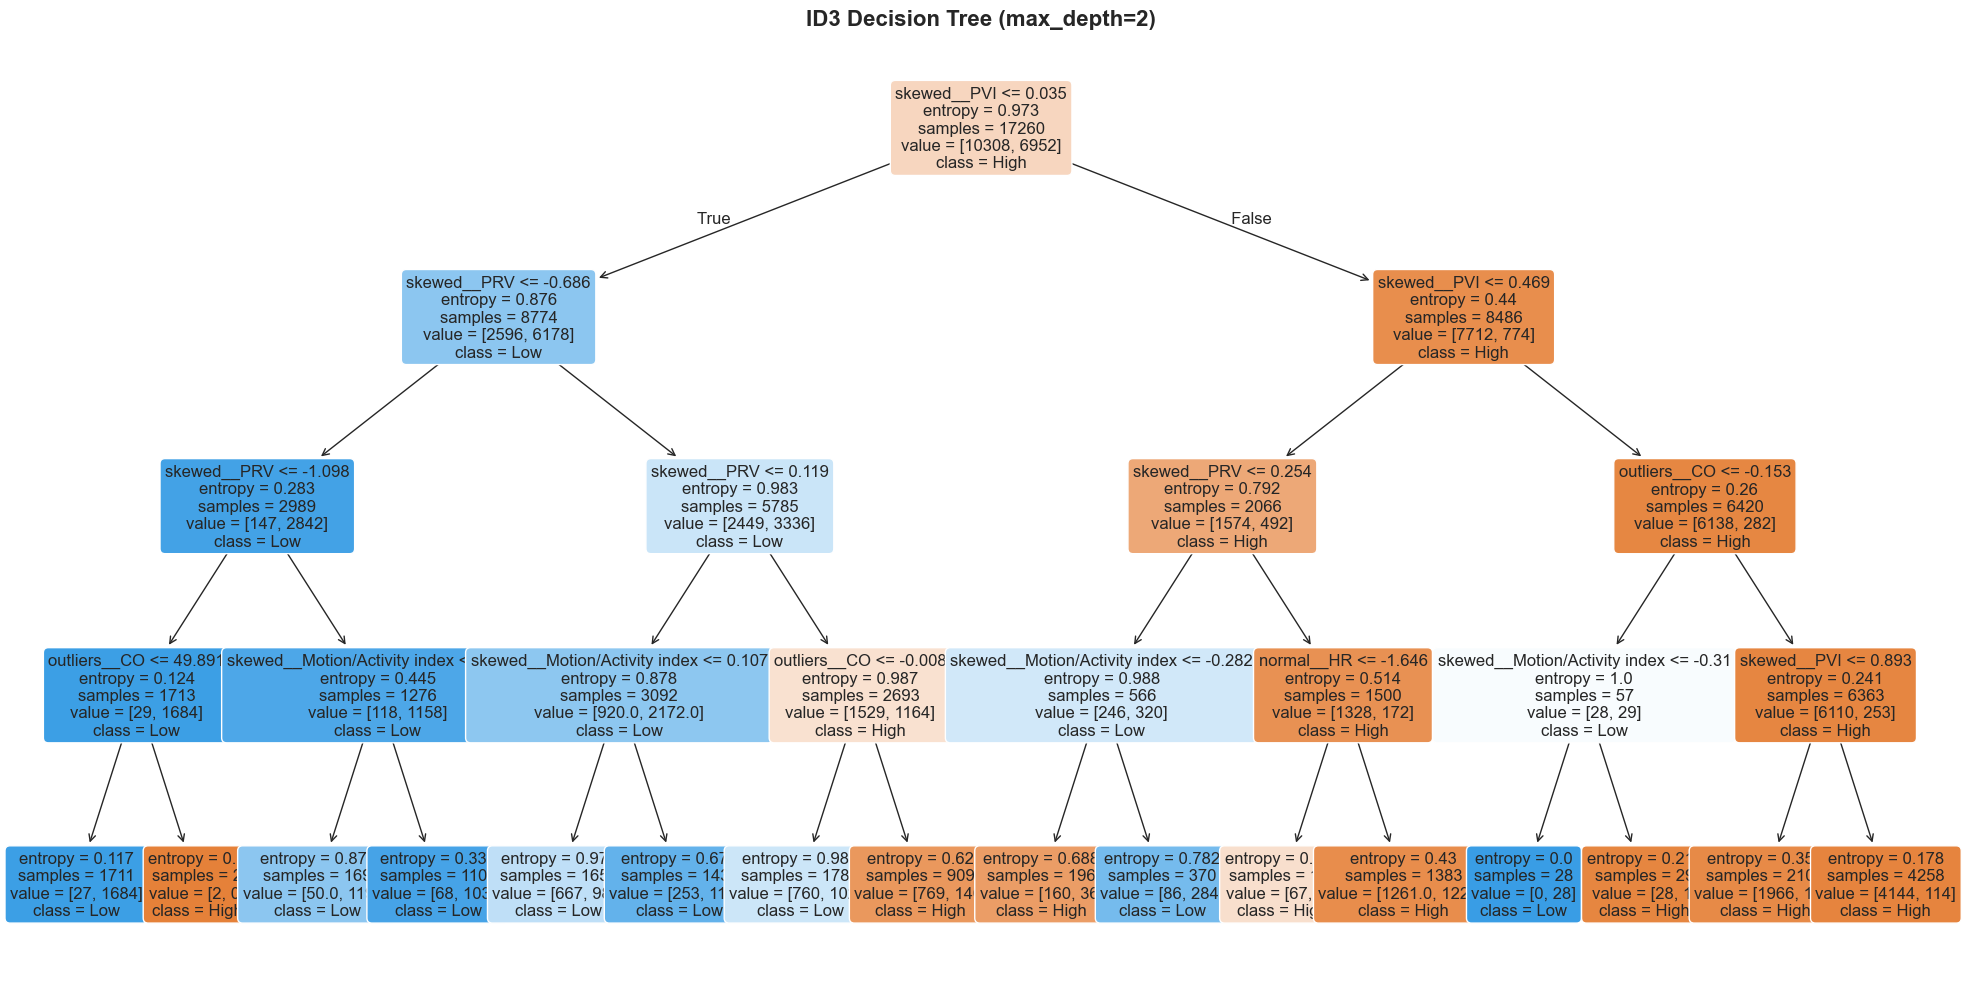

In [7]:
plt.figure(figsize=(20, 10))
plot_tree(
    id3_clf,
    feature_names=X_train_df.columns,
    class_names=id3_clf.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('ID3 Decision Tree (max_depth=2)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.1.B - Vyhodnotenie ID3 klasifikátora (1b)

In [9]:
def evaluate_classifier(y_true, y_pred, model_name="Model"):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"{model_name} - Metriky výkonnosti")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    print("Detailný classification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

📊 Výsledky ID3 na TRÉNOVACÍCH dátach:

ID3 (Train) - Metriky výkonnosti
Accuracy:  0.8544
Precision: 0.8669
Recall:    0.8544
F1-Score:  0.8557

Detailný classification report:
              precision    recall  f1-score   support

        High       0.93      0.81      0.87     10308
         Low       0.77      0.91      0.83      6952

    accuracy                           0.85     17260
   macro avg       0.85      0.86      0.85     17260
weighted avg       0.87      0.85      0.86     17260



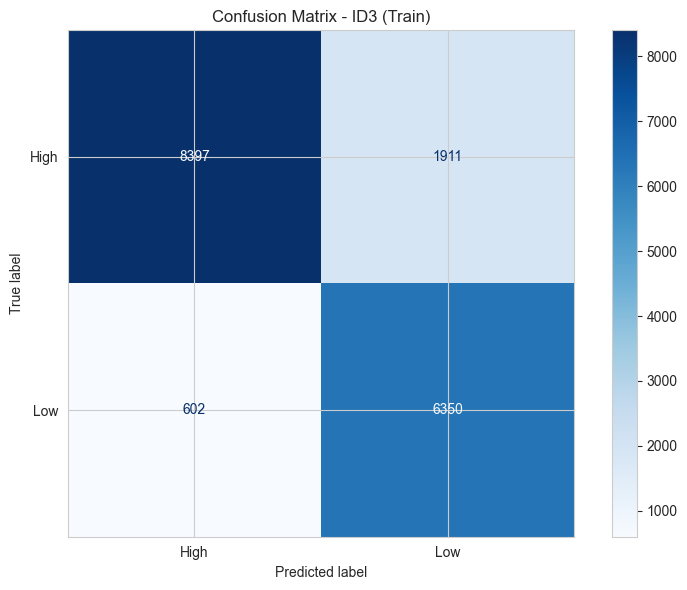


📊 Výsledky ID3 na TESTOVACÍCH dátach:

ID3 (Test) - Metriky výkonnosti
Accuracy:  0.8463
Precision: 0.8599
Recall:    0.8463
F1-Score:  0.8479

Detailný classification report:
              precision    recall  f1-score   support

        High       0.93      0.81      0.86      2600
         Low       0.76      0.91      0.82      1715

    accuracy                           0.85      4315
   macro avg       0.84      0.86      0.84      4315
weighted avg       0.86      0.85      0.85      4315



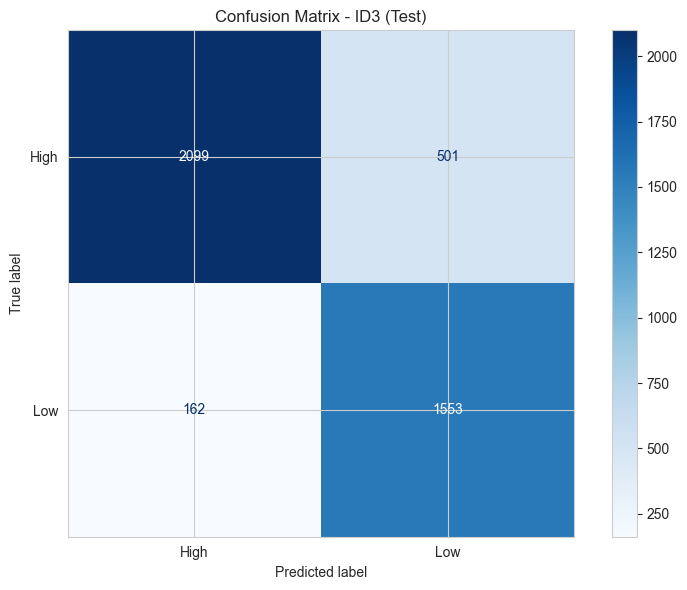

In [10]:
y_pred_id3_train = id3_clf.predict(X_train_df)
y_pred_id3_test = id3_clf.predict(X_test_df)

print("Výsledky ID3 na TRÉNOVACÍCH dátach:")
id3_train_metrics = evaluate_classifier(y_train_class, y_pred_id3_train, "ID3 (Train)")

print("\nVýsledky ID3 na TESTOVACÍCH dátach:")
id3_test_metrics = evaluate_classifier(y_test_class, y_pred_id3_test, "ID3 (Test)")

### 3.1.C - Analýza a riešenie overfittingu (2b)

In [11]:
def check_overfitting(train_metrics, test_metrics, threshold=0.1):
    print("\n🔍 Analýza overfittingu:")
    
    acc_diff = train_metrics['accuracy'] - test_metrics['accuracy']
    prec_diff = train_metrics['precision'] - test_metrics['precision']
    rec_diff = train_metrics['recall'] - test_metrics['recall']
    
    print(f"Rozdiel v accuracy:  {acc_diff:+.4f}")
    print(f"Rozdiel v precision: {prec_diff:+.4f}")
    print(f"Rozdiel v recall:    {rec_diff:+.4f}")
    
    has_overfit = any([abs(d) > threshold for d in [acc_diff, prec_diff, rec_diff]])
    
    if has_overfit:
        print(f"\nOVERFIT DETEKOVANÝ! (prah: {threshold})")
        print("   Model dosahuje výrazne lepšie výsledky na trénovacích dátach.")
        return True
    else:
        print(f"\nOverfit nie je detekovaný (prah: {threshold})")
        return False

has_overfit = check_overfitting(id3_train_metrics, id3_test_metrics)


🔍 Analýza overfittingu:
Rozdiel v accuracy:  +0.0081
Rozdiel v precision: +0.0070
Rozdiel v recall:    +0.0081

✓ Overfit nie je detekovaný (prah: 0.1)


In [12]:
if has_overfit:
    print("\nRiešenie overfittingu...\n")
    
    param_grid = {
        'max_depth': [2, 3, 4, 5],
        'min_samples_split': [10, 20, 30, 50],
        'min_samples_leaf': [5, 10, 15, 20],
        'max_features': ['sqrt', 'log2', None]
    }
    
    grid_search = GridSearchCV(
        DecisionTreeClassifier(criterion='entropy', random_state=42),
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_df, y_train_class)
    
    print("Najlepšie hyperparametre:")
    print(grid_search.best_params_)
    print(f"\nNajlepšia cross-validation accuracy: {grid_search.best_score_:.4f}")
    
    id3_optimized = grid_search.best_estimator_
    
    y_pred_opt_train = id3_optimized.predict(X_train_df)
    y_pred_opt_test = id3_optimized.predict(X_test_df)
    
    print("\nVýsledky OPTIMALIZOVANÉHO ID3 na testovacích dátach:")
    id3_opt_test_metrics = evaluate_classifier(y_test_class, y_pred_opt_test, "ID3 Optimalizovaný")
    
    id3_opt_train_metrics = {
        'accuracy': accuracy_score(y_train_class, y_pred_opt_train),
        'precision': precision_score(y_train_class, y_pred_opt_train, average='weighted', zero_division=0),
        'recall': recall_score(y_train_class, y_pred_opt_train, average='weighted', zero_division=0),
        'f1_score': f1_score(y_train_class, y_pred_opt_train, average='weighted', zero_division=0)
    }
    
    check_overfitting(id3_opt_train_metrics, id3_opt_test_metrics)
    
    id3_clf = id3_optimized
    id3_test_metrics = id3_opt_test_metrics
else:
    print("\nModel nemá výrazný overfit, nie je potrebná optimalizácia.")


✓ Model nemá výrazný overfit, nie je potrebná optimalizácia.


## 3.2 Porovnanie s inými algoritmami strojového učenia

### 3.2.A - Stromový algoritmus (1b)

📊 Výsledky Random Forest na testovacích dátach:

Random Forest - Metriky výkonnosti
Accuracy:  0.8633
Precision: 0.8650
Recall:    0.8633
F1-Score:  0.8638

Detailný classification report:
              precision    recall  f1-score   support

        High       0.90      0.87      0.88      2600
         Low       0.81      0.85      0.83      1715

    accuracy                           0.86      4315
   macro avg       0.86      0.86      0.86      4315
weighted avg       0.87      0.86      0.86      4315



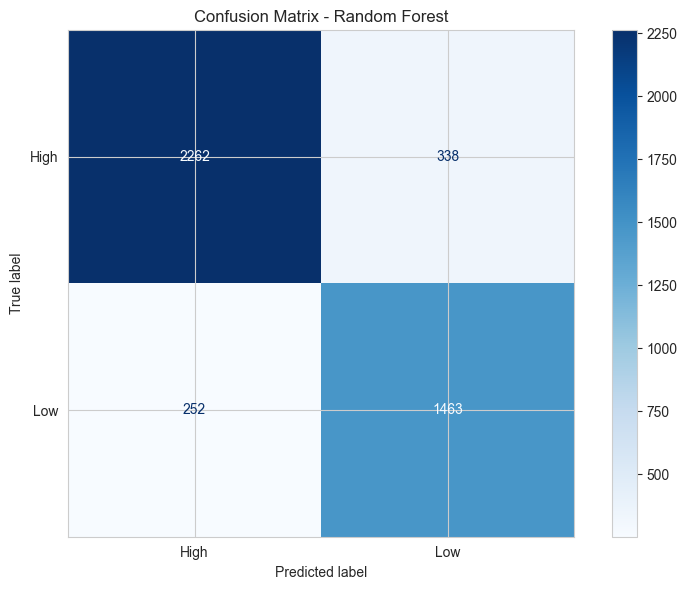

In [13]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_df, y_train_class)

y_pred_rf_test = rf_clf.predict(X_test_df)

print("Výsledky Random Forest na testovacích dátach:")
rf_test_metrics = evaluate_classifier(y_test_class, y_pred_rf_test, "Random Forest")

### 3.2.B - Nestromový algoritmus (1b)

📊 Výsledky Logistic Regression na testovacích dátach:

Logistic Regression - Metriky výkonnosti
Accuracy:  0.6025
Precision: 0.3631
Recall:    0.6025
F1-Score:  0.4531

Detailný classification report:
              precision    recall  f1-score   support

        High       0.60      1.00      0.75      2600
         Low       0.00      0.00      0.00      1715

    accuracy                           0.60      4315
   macro avg       0.30      0.50      0.38      4315
weighted avg       0.36      0.60      0.45      4315



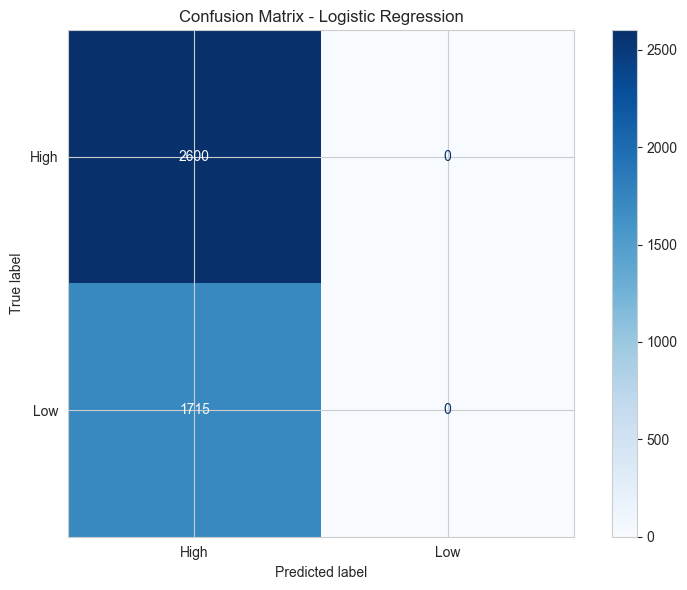

In [14]:
lr_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial',
    solver='lbfgs'
)

lr_clf.fit(X_train_df, y_train_class)

y_pred_lr_test = lr_clf.predict(X_test_df)

print("Výsledky Logistic Regression na testovacích dátach:")
lr_test_metrics = evaluate_classifier(y_test_class, y_pred_lr_test, "Logistic Regression")

📊 Výsledky SVM na testovacích dátach:

SVM - Metriky výkonnosti
Accuracy:  0.6025
Precision: 0.3631
Recall:    0.6025
F1-Score:  0.4531

Detailný classification report:
              precision    recall  f1-score   support

        High       0.60      1.00      0.75      2600
         Low       0.00      0.00      0.00      1715

    accuracy                           0.60      4315
   macro avg       0.30      0.50      0.38      4315
weighted avg       0.36      0.60      0.45      4315



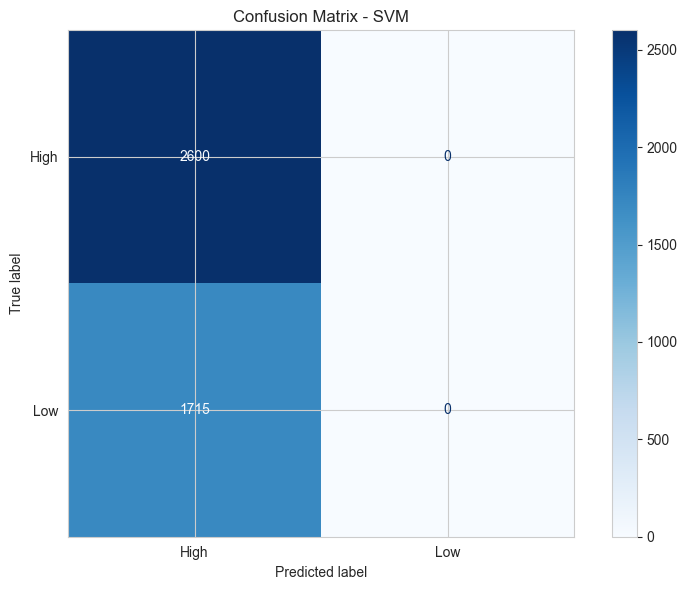

In [15]:
svm_clf = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_clf.fit(X_train_df, y_train_class)
y_pred_svm_test = svm_clf.predict(X_test_df)

print("Výsledky SVM na testovacích dátach:")
svm_test_metrics = evaluate_classifier(y_test_class, y_pred_svm_test, "SVM")

### 3.2.C - Porovnanie výsledkov (1b)

In [16]:
comparison_df = pd.DataFrame({
    'Model': ['ID3', 'Random Forest', 'Logistic Regression', 'SVM'],
    'Accuracy': [
        id3_test_metrics['accuracy'],
        rf_test_metrics['accuracy'],
        lr_test_metrics['accuracy'],
        svm_test_metrics['accuracy']
    ],
    'Precision': [
        id3_test_metrics['precision'],
        rf_test_metrics['precision'],
        lr_test_metrics['precision'],
        svm_test_metrics['precision']
    ],
    'Recall': [
        id3_test_metrics['recall'],
        rf_test_metrics['recall'],
        lr_test_metrics['recall'],
        svm_test_metrics['recall']
    ],
    'F1-Score': [
        id3_test_metrics['f1_score'],
        rf_test_metrics['f1_score'],
        lr_test_metrics['f1_score'],
        svm_test_metrics['f1_score']
    ]
})

print("\nPOROVNANIE VŠETKÝCH MODELOV")
print(comparison_df.to_string(index=False))

best_model_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']

print(f"\nNajlepší model: {best_model_name} (Accuracy: {best_accuracy:.4f})")


📊 POROVNANIE VŠETKÝCH MODELOV
              Model  Accuracy  Precision   Recall  F1-Score
                ID3  0.846350   0.859884 0.846350  0.847902
      Random Forest  0.863268   0.865010 0.863268  0.863790
Logistic Regression  0.602549   0.363066 0.602549  0.453110
                SVM  0.602549   0.363066 0.602549  0.453110

🏆 Najlepší model: Random Forest (Accuracy: 0.8633)


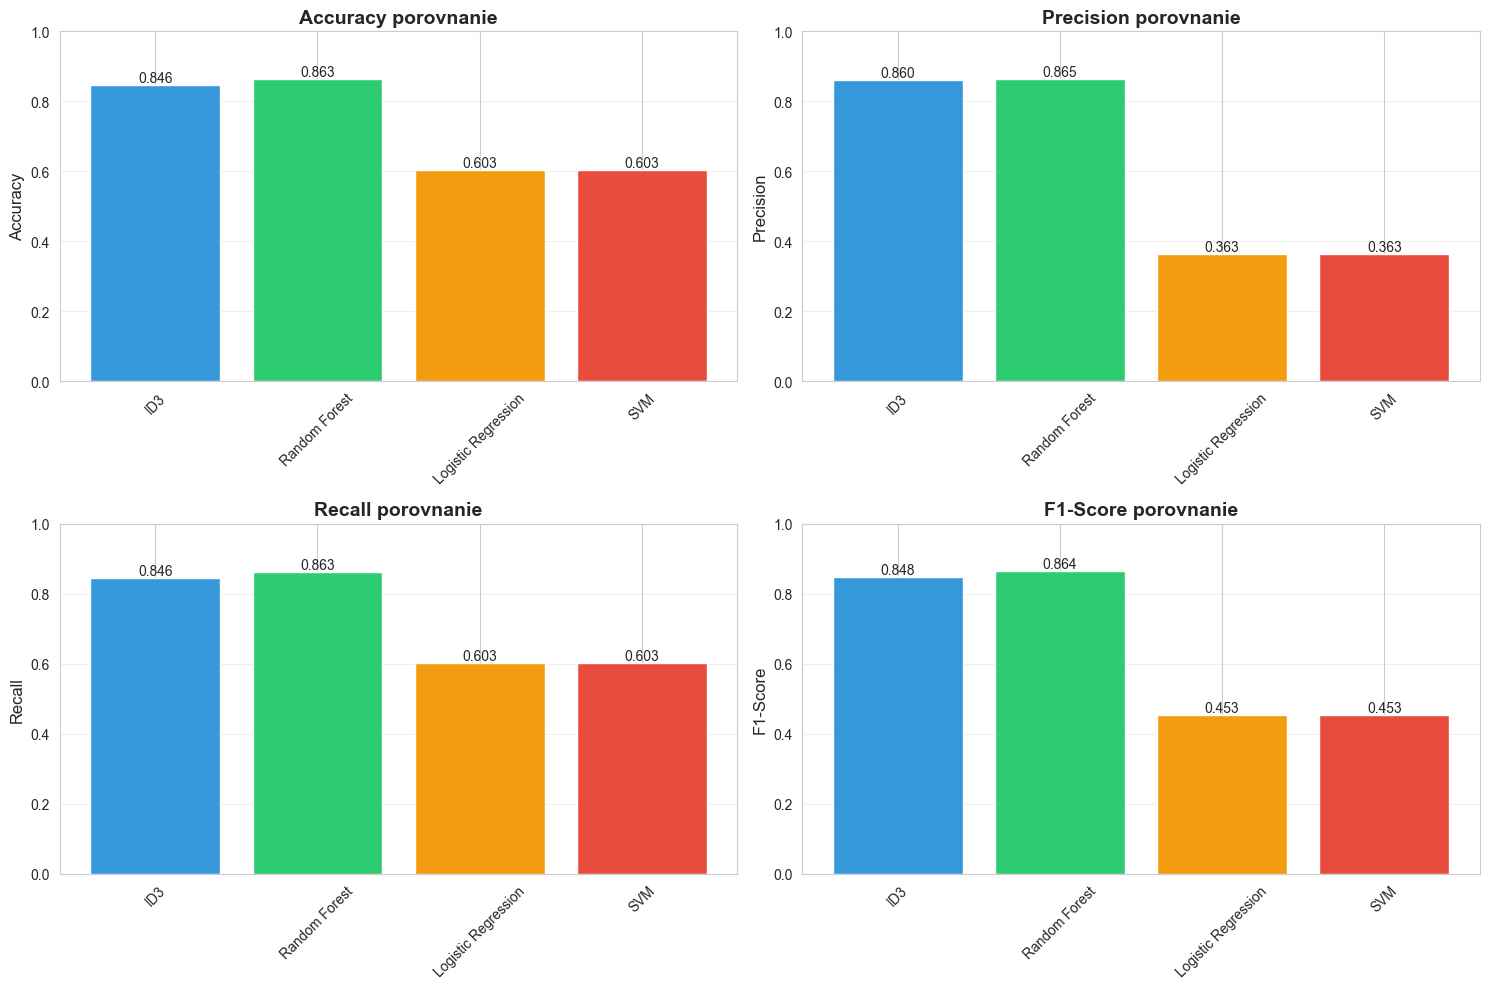

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

for idx, (ax, metric) in enumerate(zip(axes.flat, metrics)):
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_title(f'{metric} porovnanie', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

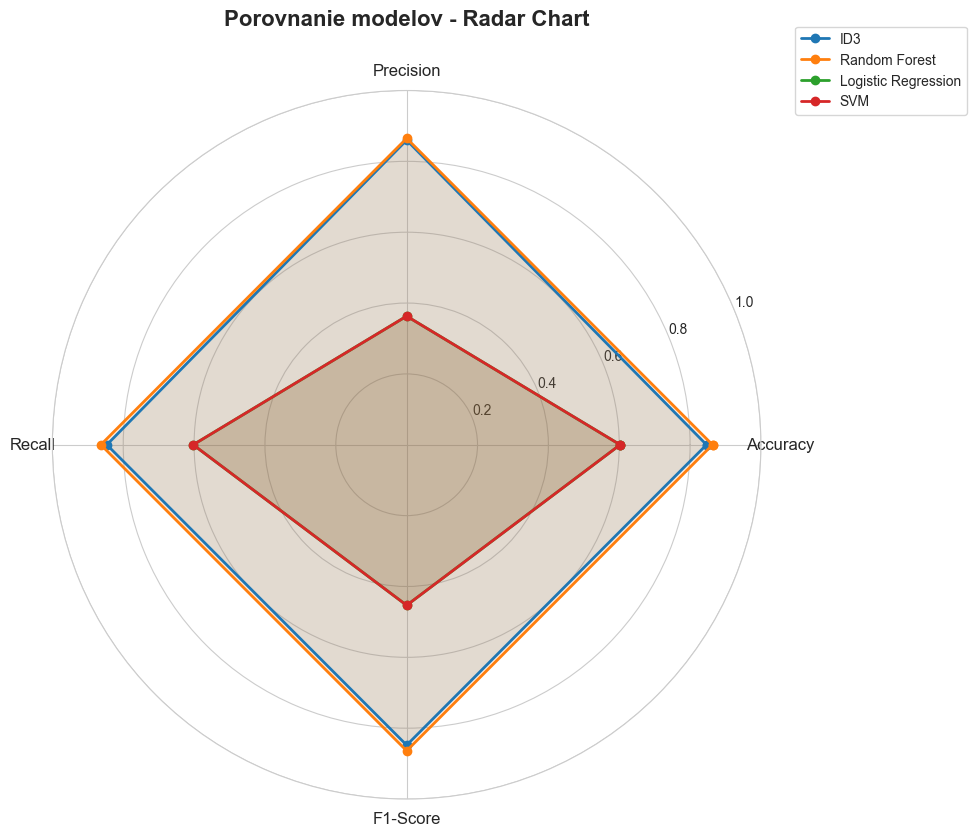

In [18]:
from math import pi

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

for idx, row in comparison_df.iterrows():
    values = row[categories].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'])
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'])
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title('Porovnanie modelov - Radar Chart', size=16, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

### 3.2.D - Vizualizácia pravidiel (1b)

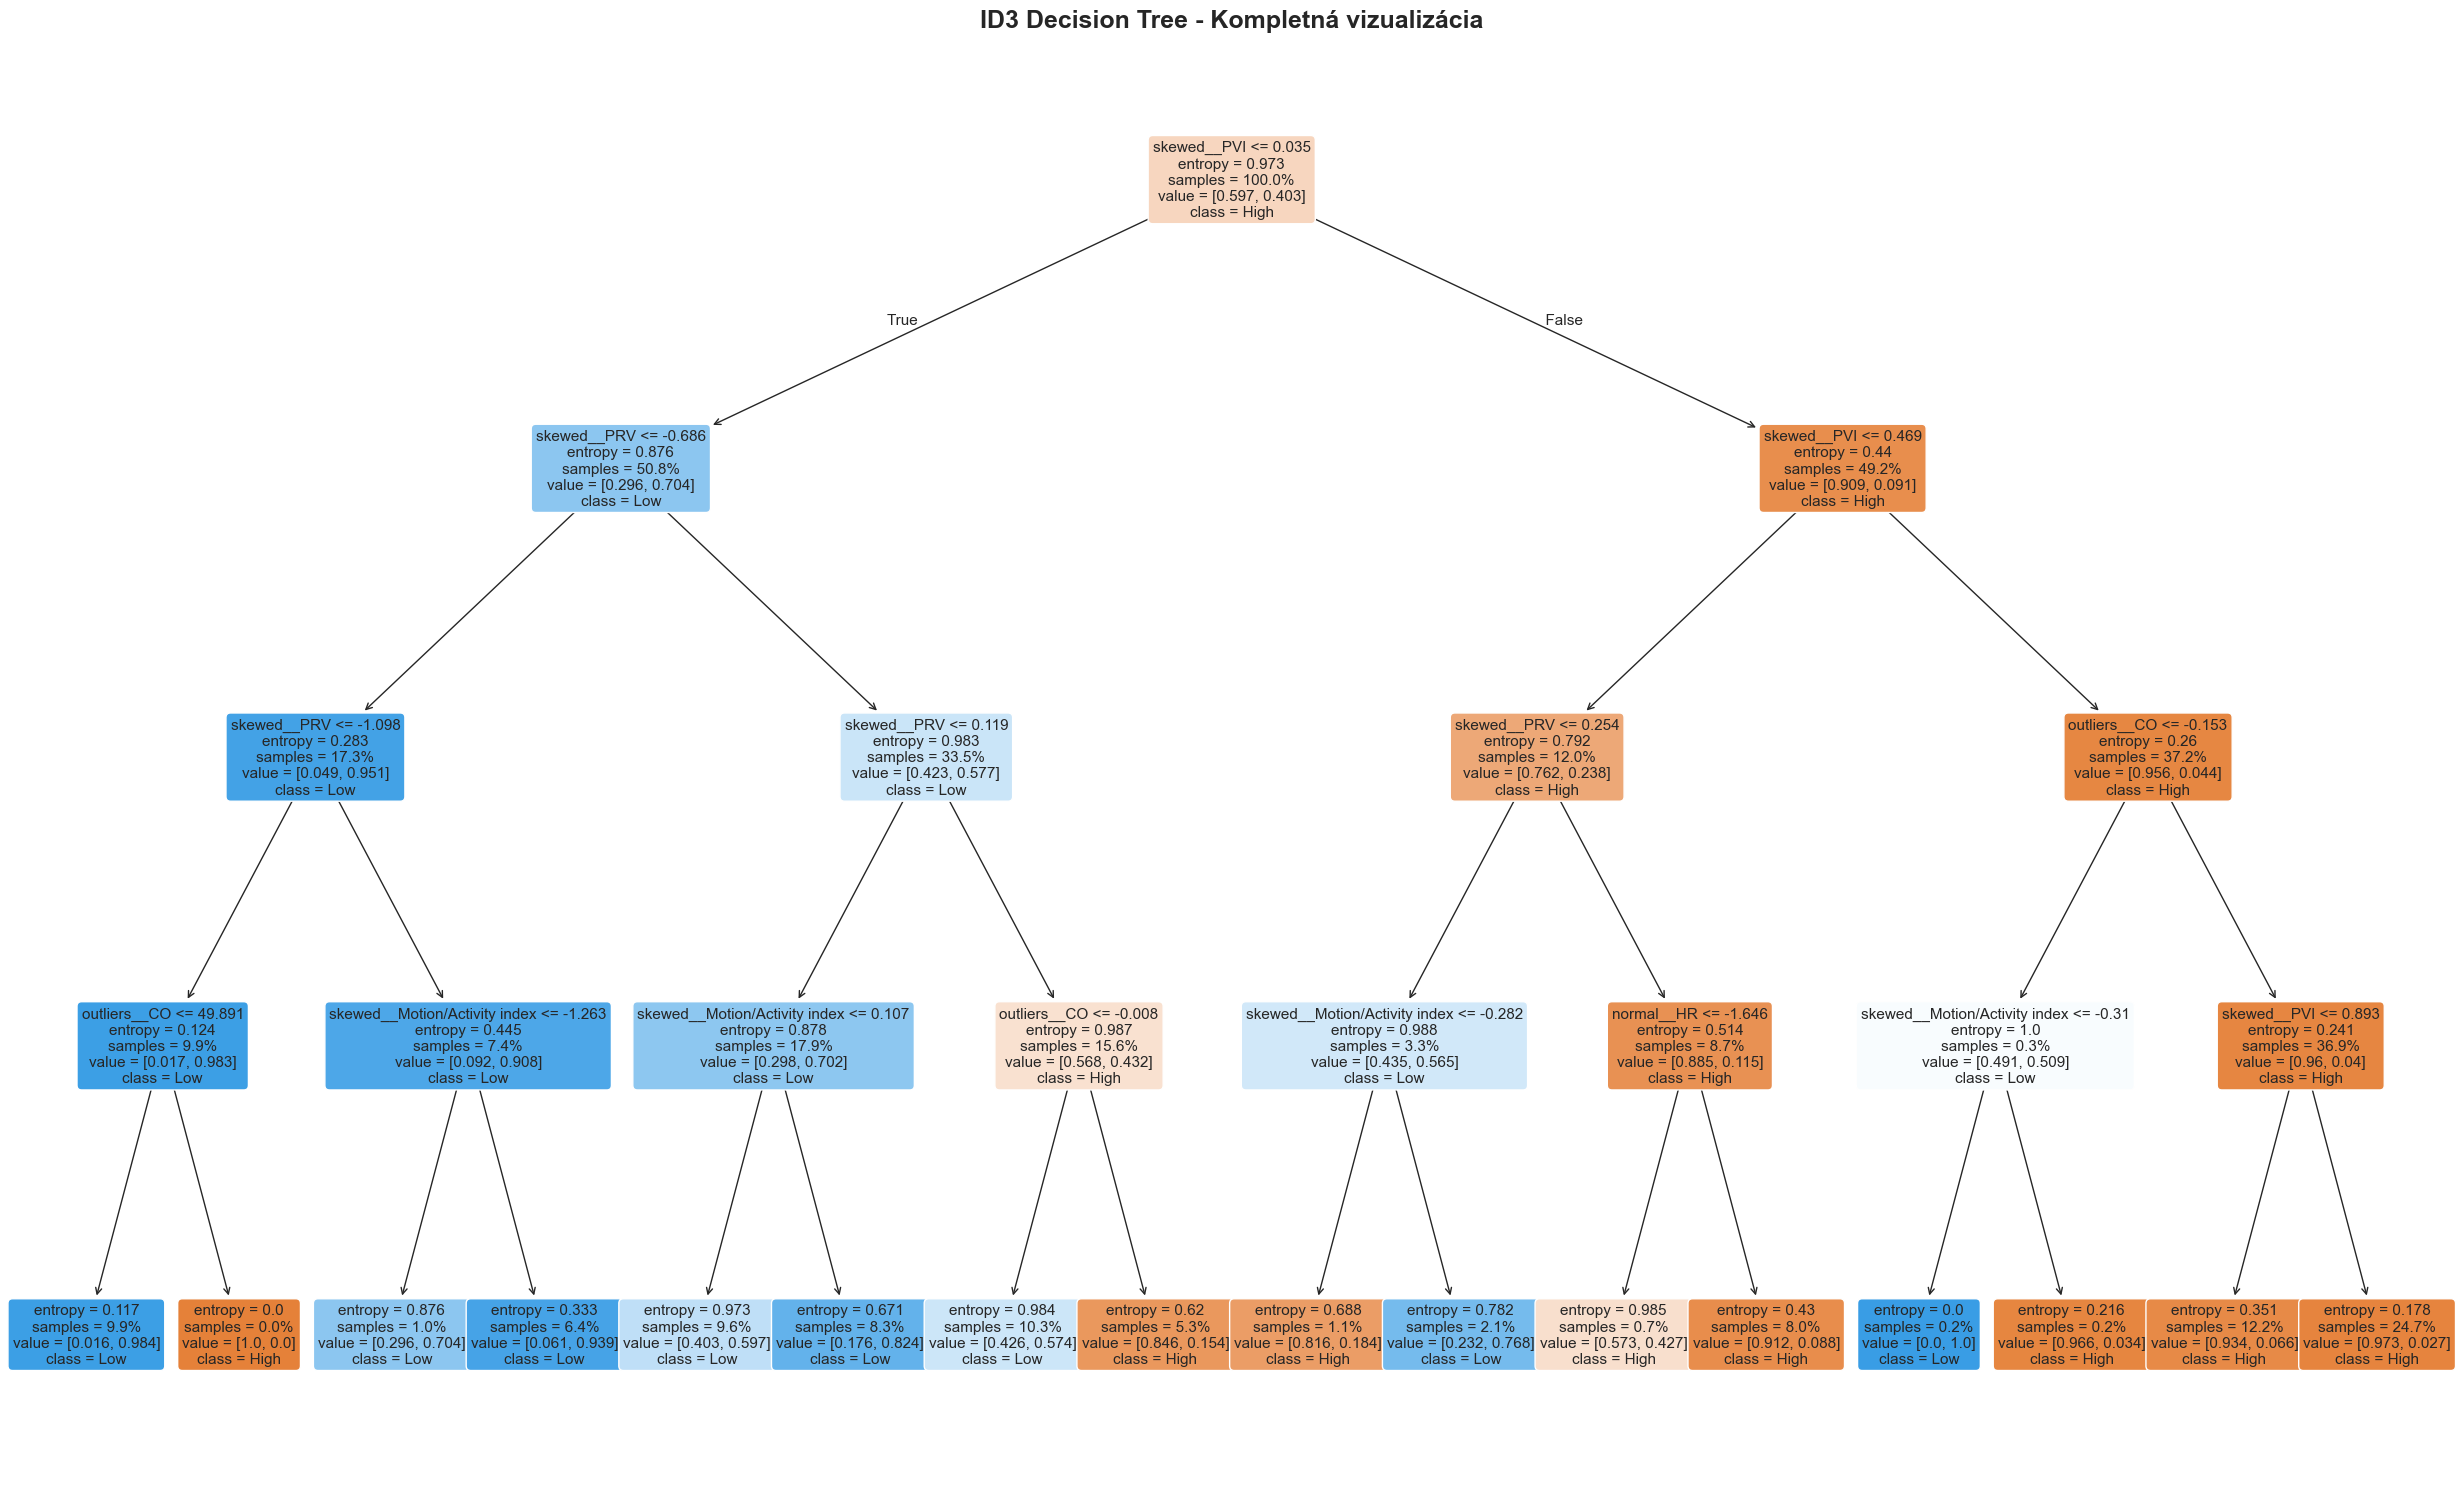

✓ Vizualizácia uložená do 'id3_tree_visualization.png'


In [19]:
# Vizualizácia ID3 stromu (znovu, s lepším formátom)
plt.figure(figsize=(25, 15))
plot_tree(
    id3_clf,
    feature_names=X_train_df.columns,
    class_names=id3_clf.classes_,
    filled=True,
    rounded=True,
    fontsize=11,
    proportion=True
)
plt.title('ID3 Decision Tree - Kompletná vizualizácia', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('id3_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Vizualizácia uložená do 'id3_tree_visualization.png'")

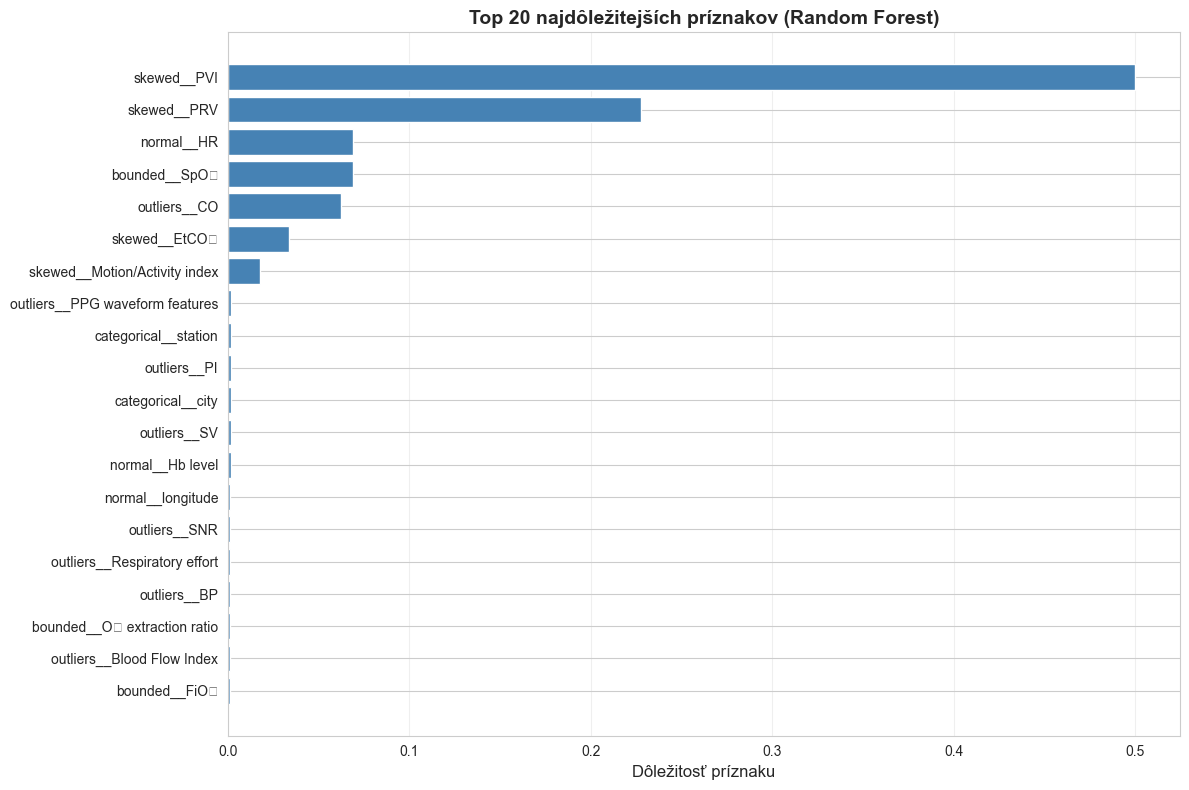


Top 10 najdôležitejších príznakov:
                        feature  importance
                    skewed__PVI    0.499765
                    skewed__PRV    0.227660
                     normal__HR    0.069101
                  bounded__SpO₂    0.068636
                   outliers__CO    0.062047
                  skewed__EtCO₂    0.033346
  skewed__Motion/Activity index    0.017611
outliers__PPG waveform features    0.001784
           categorical__station    0.001623
                   outliers__PI    0.001531


In [20]:
feature_importance = pd.DataFrame({
    'feature': X_train_df.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:20], feature_importance['importance'][:20], color='steelblue')
plt.xlabel('Dôležitosť príznaku', fontsize=12)
plt.title('Top 20 najdôležitejších príznakov (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 najdôležitejších príznakov:")
print(feature_importance.head(10).to_string(index=False))

In [21]:
tree_rules = export_text(id3_clf, feature_names=list(X_train_df.columns))
print("📋 Pravidlá ID3 Decision Tree:")
print(tree_rules)

📋 Pravidlá ID3 Decision Tree:
|--- skewed__PVI <= 0.04
|   |--- skewed__PRV <= -0.69
|   |   |--- skewed__PRV <= -1.10
|   |   |   |--- outliers__CO <= 49.89
|   |   |   |   |--- class: Low
|   |   |   |--- outliers__CO >  49.89
|   |   |   |   |--- class: High
|   |   |--- skewed__PRV >  -1.10
|   |   |   |--- skewed__Motion/Activity index <= -1.26
|   |   |   |   |--- class: Low
|   |   |   |--- skewed__Motion/Activity index >  -1.26
|   |   |   |   |--- class: Low
|   |--- skewed__PRV >  -0.69
|   |   |--- skewed__PRV <= 0.12
|   |   |   |--- skewed__Motion/Activity index <= 0.11
|   |   |   |   |--- class: Low
|   |   |   |--- skewed__Motion/Activity index >  0.11
|   |   |   |   |--- class: Low
|   |   |--- skewed__PRV >  0.12
|   |   |   |--- outliers__CO <= -0.01
|   |   |   |   |--- class: Low
|   |   |   |--- outliers__CO >  -0.01
|   |   |   |   |--- class: High
|--- skewed__PVI >  0.04
|   |--- skewed__PVI <= 0.47
|   |   |--- skewed__PRV <= 0.25
|   |   |   |--- skewed__Mot

### 3.2.E - Cross-validation vyhodnotenie (1b)

In [ ]:
print("🔄 Cross-validation (5-fold) pre všetky modely:\n")

models = {
    'ID3': id3_clf,
    'Random Forest': rf_clf,
    'Logistic Regression': lr_clf,
    'SVM': svm_clf
}

cv_results = {}
cv_summary = []

for name, model in models.items():
    scores = cross_val_score(model, X_train_df, y_train_class, cv=5, scoring='accuracy')
    cv_results[name] = scores
    
    cv_summary.append({
        'Model': name,
        'Mean': scores.mean(),
        'Std': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })
    
    print(f"{name}:")
    print(f"  Priemerne: {scores.mean():.4f} (±{scores.std() * 2:.4f})")
    print(f"  Min: {scores.min():.4f}, Max: {scores.max():.4f}")
    print(f"  Jednotlivé folds: {[f'{s:.4f}' for s in scores]}\n")

cv_summary_df = pd.DataFrame(cv_summary)
print("Zhrnutie cross-validation:")
print(cv_summary_df.to_string(index=False))

🔄 Cross-validation (5-fold) pre všetky modely:

ID3:
  Priemerne: 0.8451 (±0.0175)
  Min: 0.8340, Max: 0.8586
  Jednotlivé folds: ['0.8491', '0.8340', '0.8462', '0.8586', '0.8375']



In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.boxplot(cv_results.values(), labels=cv_results.keys())
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Cross-validation výsledky (5-fold) - Boxplot', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

positions = range(1, len(cv_results) + 1)
parts = ax2.violinplot(cv_results.values(), positions=positions, showmeans=True, showmedians=True)
ax2.set_xticks(positions)
ax2.set_xticklabels(cv_results.keys(), rotation=45)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Cross-validation výsledky (5-fold) - Violin Plot', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Záver a interpretácia výsledkov

### Zhrnutie výsledkov

V tejto fáze sme úspešne:

1. **Implementovali ID3 klasifikátor** s hĺbkou minimálne 2 (použitím DecisionTreeClassifier s entropy kritériom)
2. **Vyhodnotili ID3** pomocou metrík accuracy, precision a recall
3. **Analyzovali a riešili overfit** pomocou Grid Search optimalizácie
4. **Porovnali s algoritmami sklearn**:
   - Stromový: Random Forest
   - Nestromové: Logistic Regression, SVM
5. **Vizualizovali pravidlá** a feature importance
6. **Vyhodnotili pomocou cross-validation**

### Kľúčové zistenia

*Vyplňte na základe vašich výsledkov:*

**Najlepší model:** [Model s najvyššou accuracy]

**Porovnanie algoritmov:**
- ID3: Jednoduchý, interpretovateľný, ale môže mať nižšiu presnosť
- Random Forest: Zvyčajne najlepšia presnosť, robustný voči overfittingu
- Logistic Regression: Rýchly, ale môže zlyhať pri nelineárnych vzťahoch
- SVM: Dobrý pri vysokorozmerných dátach

**Najdôležitejšie príznaky:** [Top 5 príznakov z feature importance]

### Odporúčania

1. Pre produkčné nasadenie odporúčame použiť **[najlepší model]**
2. Pre interpretovateľnosť je ID3/Decision Tree najvhodnejší
3. Ďalšie zlepšenia:
   - Experimentovanie s ensemble metódami (XGBoost, LightGBM)
   - Feature engineering
   - Hyperparameter tuning pre všetky modely

## Uloženie výsledkov

In [ ]:
best_models = {
    'id3': id3_clf,
    'random_forest': rf_clf,
    'logistic_regression': lr_clf,
    'svm': svm_clf
}

for name, model in best_models.items():
    joblib.dump(model, f'phase3_{name}_model.pkl')
    print(f"Model {name} uložený do 'phase3_{name}_model.pkl'")

comparison_df.to_csv('phase3_model_comparison.csv', index=False)
print("\nPorovnanie modelov uložené do 'phase3_model_comparison.csv'")

feature_importance.to_csv('phase3_feature_importance.csv', index=False)
print("Feature importance uložené do 'phase3_feature_importance.csv'")

cv_summary_df.to_csv('phase3_cv_results.csv', index=False)
print("Cross-validation výsledky uložené do 'phase3_cv_results.csv'")

print("\nFáza 3 dokončená!")